In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/dmart_sales_project_500rows.csv')
df.head()
df.shape

(505, 10)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df['City']=df['City'].fillna('Unknown')
df['City'].isnull().sum()
df['Discount']=df['Discount'].fillna(0)
df['Payment_Method'].fillna('Cash',inplace=True)
df.isnull().sum().sum()


/tmp/ipykernel_850/1992247157.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment_Method'].fillna('Cash',inplace=True)


np.int64(0)

In [ ]:
df.describe()

,Order_ID,Quantity,Unit_Price,Discount,Sales
count,505.000000,505.000000,505.000000,505.00000,505.000000
mean,1250.142574,4.568317,4062.855446,14.49505,20164.861386
std,144.377054,2.197533,11638.147583,10.55468,64630.840892
min,1001.000000,1.000000,30.000000,0.00000,68.000000
25%,1125.000000,3.000000,226.000000,5.00000,876.000000
50%,1250.000000,5.000000,1149.000000,15.00000,3425.000000
75%,1375.000000,6.000000,3086.000000,25.00000,12564.000000
max,1500.000000,8.000000,65000.000000,30.00000,520000.000000


<Axes: xlabel='Sales', ylabel='Count'>

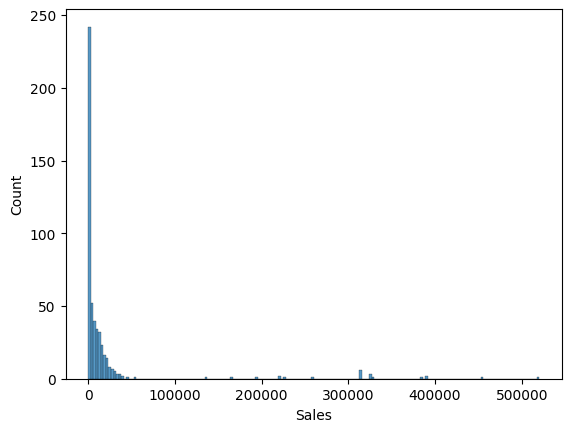

In [ ]:
sns.histplot(x='Sales',data=df)

<Axes: xlabel='Sales'>

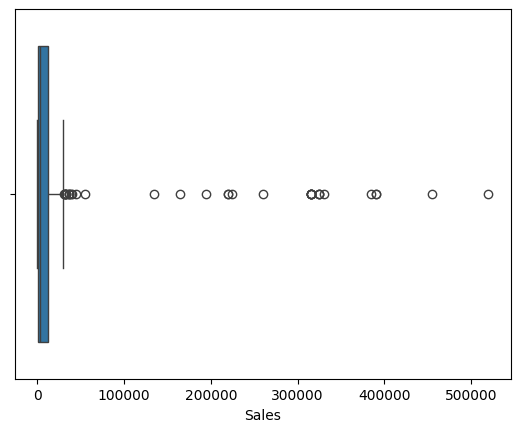

In [ ]:
sns.boxplot(x='Sales',data=df)

In [ ]:
df['Sales'].max()

520000

In [ ]:
df[df['Sales']==520000]

,Order_ID,Order_Date,City,Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Sales
318,1319,2025-03-20,Hyderabad,Electronics,Laptop,8,65000,30.0,Cash,520000


<Axes: xlabel='Sales'>

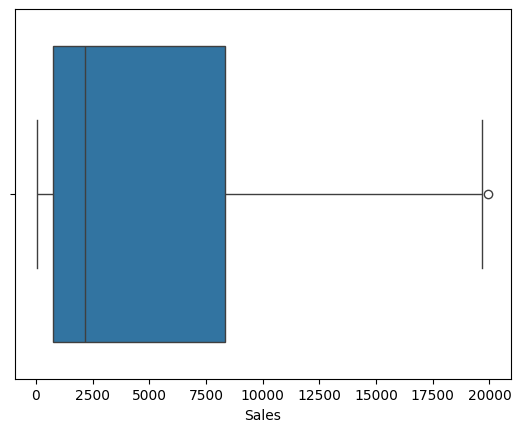

In [ ]:
dn=df[df['Sales']<=20000]
sns.boxplot(x='Sales',data=dn)


In [ ]:
outliers=df[df['Sales']>=20000]
print(outliers)

     Order_ID  Order_Date       City     Category     Product  Quantity  \
3        1004  2025-01-02      Delhi         Home         Mug         8   
6        1007  2025-03-17  Hyderabad  Electronics      Laptop         7   
11       1012  2025-01-15      Delhi      Fashion       Shoes         6   
17       1018  2025-01-03  Bengaluru  Electronics      Laptop         5   
21       1022  2025-01-29    Chennai         Home       Chair         6   
..        ...         ...        ...          ...         ...       ...   
403      1404  2025-01-22       Pune  Electronics  Headphones         8   
438      1439  2025-04-13       Pune         Home      Bucket         7   
460      1461  2025-03-25     Mumbai      Fashion       Shirt         7   
463      1464  2025-03-09      Delhi         Home      Bucket         8   
486      1487  2025-02-04  Hyderabad  Electronics      Laptop         6   

     Unit_Price  Discount Payment_Method   Sales  
3          4927      10.0            UPI   39416

In [ ]:
df["Sales"].median()

3425.0

In [ ]:
df=df.drop_duplicates()
df.duplicated().sum()


np.int64(0)

In [ ]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date']
)

/tmp/ipykernel_850/754475720.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Date'] = pd.to_datetime(


<Axes: xlabel='Category', ylabel='count'>

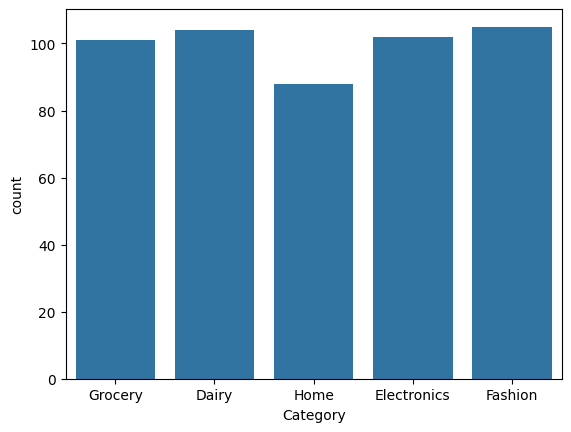

In [ ]:
sns.countplot(x='Category',data=df)

        City    Sales
0  Bengaluru  2194712
1       Pune  2011927
2  Hyderabad  1664825
3      Delhi  1482071
4     Mumbai  1364590
5    Chennai  1048440
6    Unknown   386805


<Axes: xlabel='City', ylabel='Sales'>

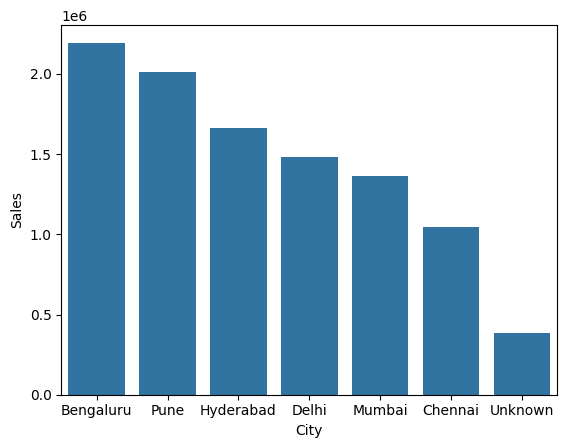

In [ ]:
New_df=df.groupby('City')['Sales'].sum().sort_values(ascending=False).reset_index()

print(New_df)
sns.barplot(x='City',y='Sales',data=New_df)

In [ ]:
df[df['City']=='Bengaluru']

,Order_ID,Order_Date,City,Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Sales
12,1013,2025-05-26,Bengaluru,Grocery,Oil,5,73,5.0,Cash,365
17,1018,2025-01-03,Bengaluru,Electronics,Laptop,5,65000,30.0,Cash,325000
42,1043,2025-04-28,Bengaluru,Dairy,Butter,6,67,0.0,Cash,402
48,1049,2025-06-12,Bengaluru,Fashion,Shoes,5,508,0.0,Card,2540
53,1054,2025-02-11,Bengaluru,Fashion,Shoes,3,1269,30.0,UPI,3807
...,...,...,...,...,...,...,...,...,...,...
443,1444,2025-04-06,Bengaluru,Grocery,Sugar,6,172,5.0,UPI,1032
451,1452,2025-03-14,Bengaluru,Dairy,Milk,2,268,30.0,Card,536
482,1483,2025-03-01,Bengaluru,Fashion,Jeans,1,669,0.0,Cash,669
495,1496,2025-05-28,Bengaluru,Fashion,Shoes,2,2263,30.0,Cash,4526


In [ ]:
tt=df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)
print(tt)

Product
Laptop        6855000
Chair          331566
Bucket         319355
Speaker        286575
Mouse          283334
Table          275478
Jeans          250219
Mug            228576
Keyboard       215421
Headphones     206749
Name: Sales, dtype: int64


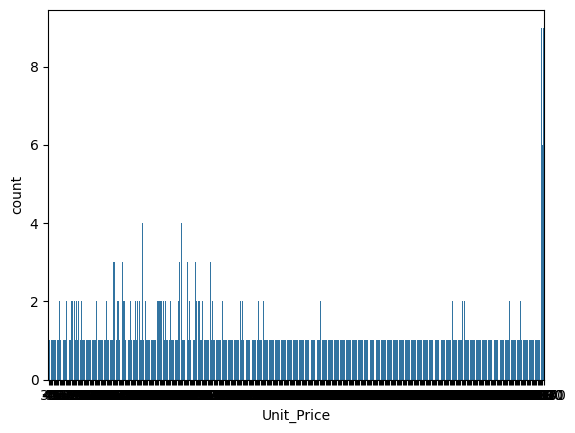

<Figure size 1800x600 with 0 Axes>

In [ ]:

sns.countplot(x='Unit_Price',data=df)
plt.figure(figsize=(18,6))
plt.show()


In [ ]:
df.groupby('Payment_Method')['Sales'].sum().sort_values(ascending=False)

,Sales
Payment_Method,
Card,4008474
Cash,3822471
UPI,2322425


([<matplotlib.patches.Wedge at 0x7a2e0232b020>,
 [Text(0.35698754073569455, 1.0404613860011724, 'Card'),
  Text(-0.9536777451216499, -0.5481776705226923, 'Cash'),
  Text(0.8280081239360292, -0.7241564379993715, 'UPI')],
 [Text(0.19472047676492427, 0.5675243923642759, '39.5%'),
  Text(-0.5201878609754453, -0.2990060021032867, '37.6%'),
  Text(0.45164079487419767, -0.39499442072692986, '22.9%')])

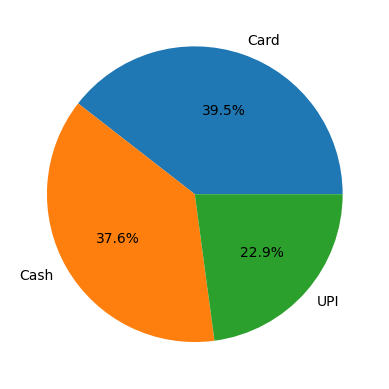

In [ ]:
plt.pie(df.groupby('Payment_Method')['Sales'].sum(),labels=df.groupby('Payment_Method')['Sales'].sum().index,autopct='%.1f%%')

   Month_No     Month    Sales
0         1   January  2008546
1         2  February  1556710
2         3     March  2227164
3         4     April  2378246
4         5       May  1350906
5         6      June   631798


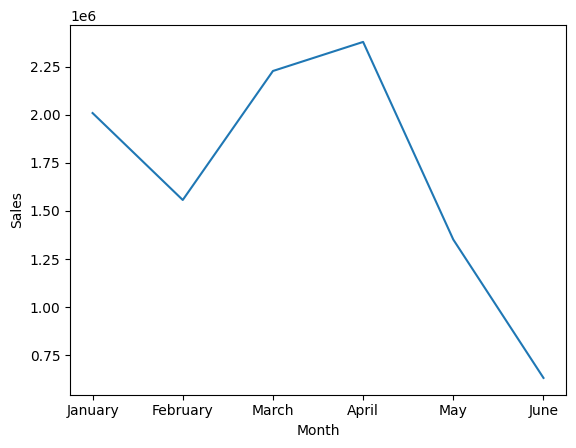

In [ ]:
df['Month_No'] = df['Order_Date'].dt.month
df['Month'] = df['Order_Date'].dt.strftime('%B')

monthly_sales = (
    df.groupby(['Month_No','Month'])['Sales']
      .sum()
      .reset_index()
      .sort_values('Month_No')
)

print(monthly_sales)
sns.lineplot(x='Month',y='Sales',data=monthly_sales)
plt.show()

In [ ]:
co=df.corr(numeric_only=True)

<Axes: >

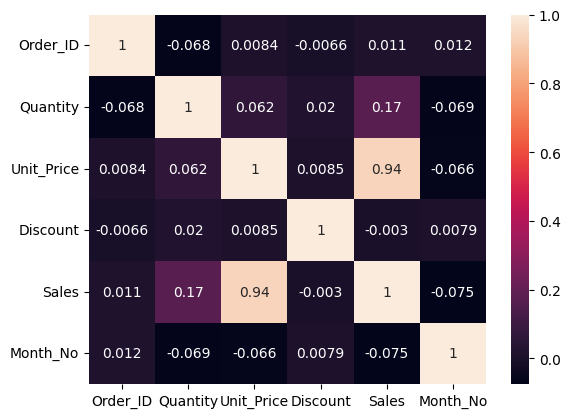

In [ ]:
sns.heatmap(co,annot=True)

In [ ]:
df[['Quantity','Sales']].corr(numeric_only=True)

,Quantity,Sales
Quantity,1.000000,0.172029
Sales,0.172029,1.000000


<Axes: xlabel='Quantity', ylabel='Sales'>

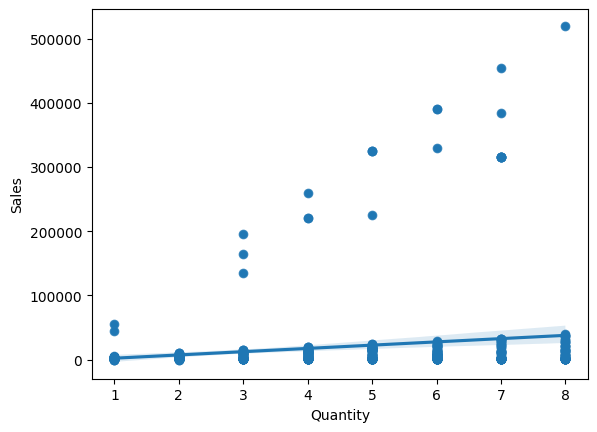

In [ ]:
sns.scatterplot(x='Quantity',y='Sales',data=df)
sns.regplot(x='Quantity',y='Sales',data=df)

<Axes: xlabel='Unit_Price', ylabel='Sales'>

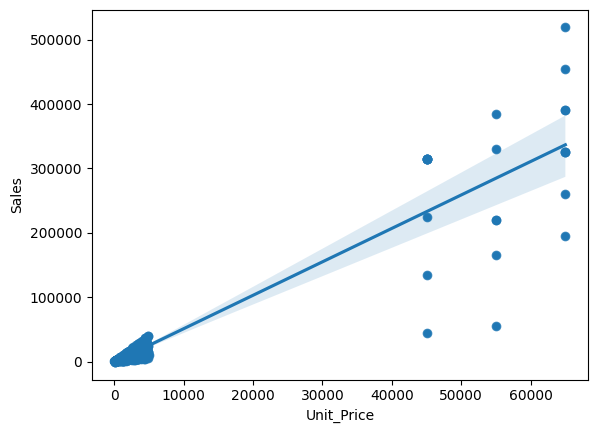

In [ ]:
sns.scatterplot(x='Unit_Price',y='Sales',data=df)
sns.regplot(x='Unit_Price',y='Sales',data=df)

In [ ]:
df.groupby('Category')['Discount'].mean()

,Discount
Category,
Dairy,14.615385
Electronics,14.656863
Fashion,14.714286
Grocery,14.900990
Home,13.295455


In [ ]:
df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(5)

,Sales
Product,
Laptop,6855000
Chair,331566
Bucket,319355
Speaker,286575
Mouse,283334


3416.5